<a href="https://colab.research.google.com/github/VivekOPest/gaia-symbolic-regression/blob/main/01_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Feature Engineering

This notebook derives additional astrophysical quantities from the Gaia DR3 dataset.

The derived features are physically meaningful and will later be used as inputs for symbolic regression.

In [32]:
import pandas as pd
import numpy as np
from pathlib import Path

In [33]:
DATA_PATH = "gaia_sample.csv"

df = pd.read_csv(DATA_PATH)

print(df.head())

            source_id  parallax  parallax_error  parallax_over_error  \
0  137341754068386432  0.933154        0.051944            17.964705   
1  137342166385242112  4.299332        0.022674           189.618150   
2  137348900893898240  0.796858        0.042952            18.552425   
3  137351615313312384  1.354746        0.018821            71.981310   
4  137355326165033472  1.222841        0.056203            21.757740   

       ruwe  phot_g_mean_mag  phot_bp_mean_mag  phot_rp_mean_mag     bp_rp  \
0  1.036885        16.108717         16.661566         15.408920  1.252646   
1  1.026791        14.220328         15.037620         13.338170  1.699450   
2  1.002285        15.707364         16.114141         15.123431  0.990710   
3  1.202068        12.139791         12.538257         11.568266  0.969991   
4  1.006233        16.461163         17.241302         15.604395  1.636908   

   teff_gspphot  radius_gspphot  
0     4896.8936          0.8375  
1     4397.8647          0.709

## Computing Distance

Gaia measures stellar parallax in milliarcseconds (mas).

Distance is calculated using

d(pc) = 1000 / parallax(mas)

where

• d is the distance in parsecs
• parallax is measured in milliarcseconds.

In [34]:
df["distance_pc"] = 1000 / df["parallax"]

In [35]:
df[["parallax", "distance_pc"]].head()

,parallax,distance_pc
0,0.933154,1071.634077
1,4.299332,232.594299
2,0.796858,1254.928641
3,1.354746,738.145960
4,1.222841,817.767640


## Computing Absolute Magnitude

Gaia provides apparent magnitude.

Absolute magnitude represents the intrinsic brightness of a star and is calculated using the distance modulus equation.

M = m - 5 log10(d) + 5

where

m = apparent magnitude

d = distance in parsecs

In [36]:
df["absolute_g_mag"] = (
    df["phot_g_mean_mag"]
    - 5*np.log10(df["distance_pc"])
    + 5
)

In [37]:
df[
    [
        "phot_g_mean_mag",
        "distance_pc",
        "absolute_g_mag"
    ]
].head()

,phot_g_mean_mag,distance_pc,absolute_g_mag
0,16.108717,1071.634077,5.958484
1,14.220328,232.594299,7.387333
2,15.707364,1254.928641,5.214269
3,12.139791,738.145960,2.799080
4,16.461163,817.767640,6.898013


In [38]:
selected = df[
    [
        "teff_gspphot",
        "bp_rp",
        "distance_pc",
        "absolute_g_mag",
        "radius_gspphot"
    ]
]

In [39]:
selected.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   teff_gspphot    20000 non-null  float64
 1   bp_rp           20000 non-null  float64
 2   distance_pc     20000 non-null  float64
 3   absolute_g_mag  20000 non-null  float64
 4   radius_gspphot  20000 non-null  float64
dtypes: float64(5)
memory usage: 781.4 KB


In [40]:
selected.isnull().sum()

,0
teff_gspphot,0
bp_rp,0
distance_pc,0
absolute_g_mag,0
radius_gspphot,0


In [41]:
selected = selected.dropna()

In [42]:
selected.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   teff_gspphot    20000 non-null  float64
 1   bp_rp           20000 non-null  float64
 2   distance_pc     20000 non-null  float64
 3   absolute_g_mag  20000 non-null  float64
 4   radius_gspphot  20000 non-null  float64
dtypes: float64(5)
memory usage: 781.4 KB


In [47]:
selected.to_csv(
    "gaia_features.csv",
    index=False
)

In [45]:
selected.head()

,teff_gspphot,bp_rp,distance_pc,absolute_g_mag,radius_gspphot
0,4896.8936,1.252646,1071.634077,5.958484,0.8375
1,4397.8647,1.699450,232.594299,7.387333,0.7090
2,5307.8760,0.990710,1254.928641,5.214269,0.7948
3,5952.5596,0.969991,738.145960,2.799080,2.3795
4,4525.4976,1.636908,817.767640,6.898013,0.8585


In [48]:
import os

print(os.getcwd())

/content


In [49]:
os.listdir()

['.config', 'sample_data', 'gaia_features.csv', 'gaia_sample.csv', 'drive']

In [50]:
from google.colab import files

files.download("gaia_features.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [51]:
print(selected.describe())

       teff_gspphot         bp_rp   distance_pc  absolute_g_mag  \
count  20000.000000  20000.000000  20000.000000    20000.000000   
mean    5137.109465      1.399267   1143.525903        5.692793   
std     1123.945195      0.571870    737.890442        2.377690   
min     2725.162400     -0.060136     36.583421       -3.361497   
25%     4458.739700      0.994104    612.665684        4.132417   
50%     5140.719700      1.219895   1008.959641        5.386425   
75%     5756.013750      1.642462   1478.423064        7.088513   
max    34999.370000      4.945676   6271.930714       13.962065   

       radius_gspphot  
count    20000.000000  
mean         1.596792  
std          6.192113  
min          0.152300  
25%          0.667175  
50%          0.860800  
75%          1.275725  
max        608.047700  


In [56]:
selected.min()
selected.max()

,0
teff_gspphot,34999.370000
bp_rp,4.945676
distance_pc,6271.930714
absolute_g_mag,13.962065
radius_gspphot,608.047700


(array([1.9765e+04, 1.5900e+02, 3.4000e+01, 2.6000e+01, 6.0000e+00,
        2.0000e+00, 0.0000e+00, 2.0000e+00, 1.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00,
        2.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00]),
 array([1.52300000e-01, 1.23102080e+01, 2.44681160e+01, 3.66260240e+01,
        4.87839320e+01, 6.09418400e+01, 7.30997480e+01, 8.52576560e+01,
        9.74155640e+01, 1.09573472e+02, 1.21731380e+02, 1.33889288e+02,
        1.46047196e+02, 1.58205104e+02, 1.70363012e+02, 1.82520920e+02,
        1.94678828e+02, 2.0683

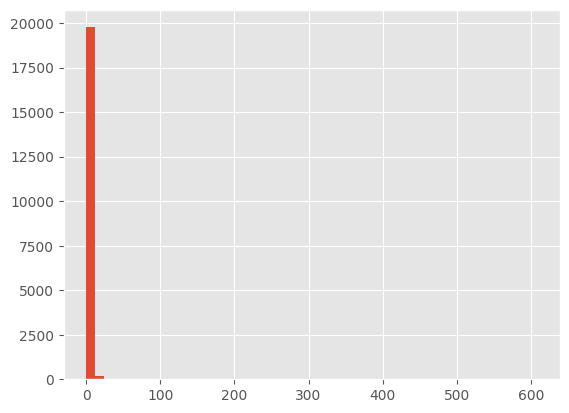

In [57]:
plt.hist(selected["radius_gspphot"], bins=50)

(array([6.810e+02, 2.460e+03, 3.301e+03, 4.907e+03, 5.165e+03, 2.300e+03,
        5.940e+02, 2.440e+02, 9.200e+01, 9.400e+01, 1.010e+02, 2.400e+01,
        1.100e+01, 7.000e+00, 3.000e+00, 2.000e+00, 4.000e+00, 1.000e+00,
        1.000e+00, 5.000e+00, 1.000e+00, 0.000e+00, 1.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 1.000e+00]),
 array([ 2725.1624  ,  3370.646552,  4016.130704,  4661.614856,
         5307.099008,  5952.58316 ,  6598.067312,  7243.551464,
         7889.035616,  8534.519768,  9180.00392 ,  9825.488072,
        10470.972224, 11116.456376, 11761.940528, 12407.42468 ,
        13052.908832, 13698.392984, 14343.877136, 14989.361288,
        15634.84544 , 16280.329592, 16925.813744, 17571.

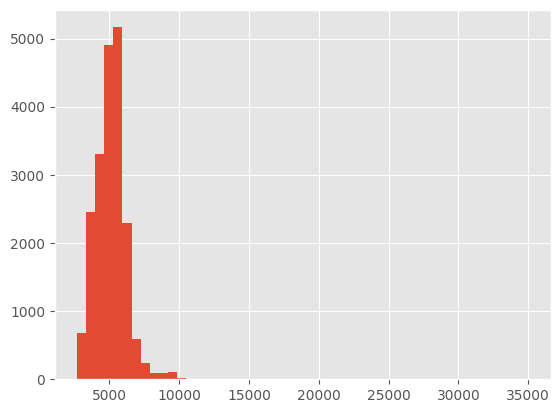

In [58]:
plt.hist(selected["teff_gspphot"], bins=50)

(array([1.000e+00, 1.000e+00, 1.000e+00, 2.000e+00, 3.000e+00, 1.100e+01,
        1.100e+01, 2.200e+01, 2.600e+01, 4.600e+01, 8.600e+01, 1.800e+02,
        1.710e+02, 1.620e+02, 1.710e+02, 1.820e+02, 2.300e+02, 3.570e+02,
        5.820e+02, 7.940e+02, 1.151e+03, 1.285e+03, 1.410e+03, 1.388e+03,
        1.365e+03, 1.321e+03, 1.101e+03, 1.093e+03, 9.290e+02, 7.770e+02,
        7.150e+02, 6.090e+02, 5.170e+02, 4.650e+02, 3.990e+02, 3.810e+02,
        3.700e+02, 3.630e+02, 3.250e+02, 2.760e+02, 2.470e+02, 1.660e+02,
        1.160e+02, 9.100e+01, 4.500e+01, 2.200e+01, 2.000e+01, 1.100e+01,
        2.000e+00, 1.000e+00]),
 array([-3.36149657, -3.01502534, -2.66855411, -2.32208288, -1.97561165,
        -1.62914042, -1.28266919, -0.93619796, -0.58972674, -0.24325551,
         0.10321572,  0.44968695,  0.79615818,  1.14262941,  1.48910064,
         1.83557187,  2.1820431 ,  2.52851433,  2.87498556,  3.22145678,
         3.56792801,  3.91439924,  4.26087047,  4.6073417 ,  4.95381293,
         5.

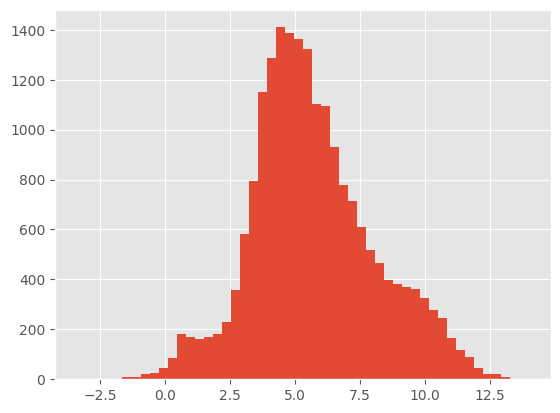

In [59]:
plt.hist(selected["absolute_g_mag"], bins=50)

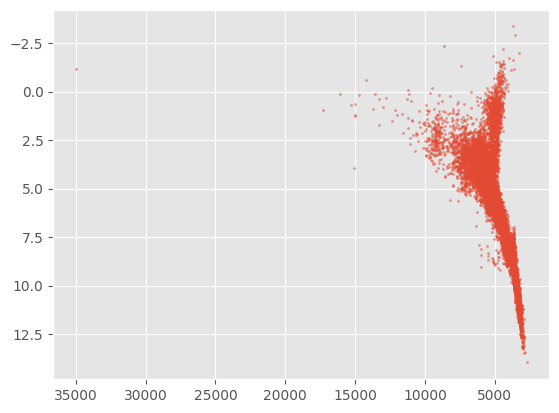

In [60]:
plt.scatter(
    selected["teff_gspphot"],
    selected["absolute_g_mag"],
    s=2,
    alpha=0.5
)

plt.gca().invert_xaxis()
plt.gca().invert_yaxis()